## gCRL-AE applied on the Joung2023 dataset

- Load processed Joung2023 dataset
- Compute eigengenes
- Train gCRL-AE
- Partial MCC permutation analysis

In [1]:
# ensuring all packages are reloaded each time I run a cell
%load_ext autoreload
%autoreload 2

In [2]:
# importing
import scanpy as sc
from gcrl.training.train_gcrl_ae import train_gcrl_ae
from gcrl.grn.eigengenes import compute_eigengenes
from gcrl.alignment.partial_mcc_perm_experiments import run_partial_mcc_perm_experiments
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import itertools
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from gcrl.models.gcrl_ae import GCRLAE
from gcrl.training.train_gcrl_ae import _to_dense, _zscore_using_reference, _ref_indices_from_query


In [3]:
# setting paths
input_data_folder = '../../data/real/Joung2023/'
input_data_file = input_data_folder + 'Joung2023_processed.h5ad'
output_data_folder = '../../results/real/Joung2023/'
results_folder = '../../results/real/Joung2023/'

In [5]:
# loading data
adata = sc.read_h5ad(input_data_file)

In [6]:
# computing eigengenes
compute_eigengenes(adata, mode="all_cells")
adata

AnnData object with n_obs × n_vars = 46404 × 1795
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'batchTF', 'score', 'temp', 'dpt_pseudotime', 'm3_pseudotime', 'ORF_ID', 'TF_name', 'tmp', 'is_differentiated', 'is_combinatorially_tested', 'control_type', 'cell_type', 'intervention'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std', 'gene_symbols', 'kind', 'community'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap', 'X_comm_eig_comm_ids', 'X_comm_eig_global_index', 'comm_eig_meta'
    obsm: 'X_pca', 'X_umap', 'X_comm_eig'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'

In [7]:
# explained variance ratio per eigengene
# Works with both mode="by_cell_type" (averages across cell types) and
# mode="all_cells" / mode="global" (single global computation).
meta = adata.uns["comm_eig_meta"]
comm_ids = adata.uns["X_comm_eig_comm_ids"]

rows = []
if meta["mode"] == "by_cell_type":
    for ct, ct_meta in meta["per_cell_type"].items():
        for comm in comm_ids:
            evr = ct_meta["per_comm_stats"][str(comm)]["explained_variance_ratio"]
            n_tfs = len(ct_meta["per_comm_genes"][str(comm)])
            rows.append({"cell_type": ct, "community": comm, "n_tfs": n_tfs, "explained_variance_ratio": evr})
        rows.append({
            "cell_type": ct,
            "community": "all_TF",
            "n_tfs": sum(len(ct_meta["per_comm_genes"][str(c)]) for c in comm_ids),
            "explained_variance_ratio": ct_meta["pooled_tf_stats"]["explained_variance_ratio"],
        })
else:  # "global" or "all_cells"
    for comm in comm_ids:
        evr = meta["per_comm_stats"][str(comm)]["explained_variance_ratio"]
        n_tfs = len(meta["per_comm_genes"][str(comm)])
        rows.append({"cell_type": "all", "community": comm, "n_tfs": n_tfs, "explained_variance_ratio": evr})
    rows.append({
        "cell_type": "all",
        "community": "all_TF",
        "n_tfs": sum(len(meta["per_comm_genes"][str(c)]) for c in comm_ids),
        "explained_variance_ratio": meta["pooled_tf_stats"]["explained_variance_ratio"],
    })

df_evr = pd.DataFrame(rows)
summary = (
    df_evr.groupby("community")
    .agg(n_tfs=("n_tfs", "first"), mean_evr=("explained_variance_ratio", "mean"))
    .rename(columns={"mean_evr": "explained_variance_ratio (mean across cell types)"})
)

# correlation between n_tfs and mean EVR (excluding pooled all_TF row)
comm_only = summary.drop(index="all_TF", errors="ignore")
r_pearson, p_pearson = pearsonr(comm_only["n_tfs"], comm_only["explained_variance_ratio (mean across cell types)"])
r_spearman, p_spearman = spearmanr(comm_only["n_tfs"], comm_only["explained_variance_ratio (mean across cell types)"])

summary["explained_variance_ratio (mean across cell types)"] = (
    summary["explained_variance_ratio (mean across cell types)"] * 100
).round(1).astype(str) + "%"
print(f"Eigengene mode: {meta['mode']}\n")
print(summary.to_string())
print("\nCorrelation between n_tfs and explained variance ratio (communities only):")
print(f"  Pearson  r = {r_pearson:+.3f}  (p = {p_pearson:.3g})")
print(f"  Spearman r = {r_spearman:+.3f}  (p = {p_spearman:.3g})")


Eigengene mode: all_cells

           n_tfs explained_variance_ratio (mean across cell types)
community                                                         
0.0           23                                              5.4%
1.0           15                                              7.0%
2.0           14                                              7.9%
3.0           14                                              8.1%
4.0           11                                             10.1%
5.0            9                                             12.0%
6.0            9                                             11.9%
7.0            8                                             13.1%
8.0            8                                             13.1%
9.0            8                                             13.2%
10.0           7                                             16.2%
11.0           5                                             20.8%
all_TF       131                   

In [8]:
# TF communities targeted by at least one intervention

# flatten single and double perturbations to individual TF names
interventions = adata.obs["intervention"].unique()
perturbed_tfs = set(
    itertools.chain.from_iterable(i.split("+") for i in interventions if i != "unperturbed")
)

# map each perturbed TF to its community (TFs only, drop NaN community)
tf_var = adata.var.loc[adata.var["kind"] == "TF", ["community"]].dropna()
perturbed_tf_var = tf_var[tf_var.index.isin(perturbed_tfs)]
perturbed_tf_var['gene_symbols'] = perturbed_tf_var.index

# group by community: collect the perturbed TFs per community
community_to_tfs = (
    perturbed_tf_var.reset_index()
    .groupby("community")["gene_symbols"]
    .apply(sorted)
    .apply(list)
)

print(f"Unique perturbed TFs: {len(perturbed_tfs)}")
print(f"Communities targeted: {sorted(community_to_tfs.index.astype(int).tolist())}\n")
for comm, tfs in community_to_tfs.items():
    print(f"  Community {int(comm):2d}  ({len(tfs):2d} perturbed TFs): {', '.join(tfs)}")

Unique perturbed TFs: 79
Communities targeted: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

  Community  0  (17 perturbed TFs): CDX2, CTCFL, HES5, HOXA6, HOXB8, HOXC6, HOXC8, HOXC9, ISL1, NR2F2, OSR2, PAX2, PAX7, PRRX1, RFX3, TCF4, THRB
  Community  1  ( 7 perturbed TFs): EGR3, FOXO3, HMX1, NEUROG1, PAX3, PITX2, PPARD
  Community  2  ( 9 perturbed TFs): AR, CREB5, EOMES, ESRRG, FOXP1, FOXP2, FOXP3, HOXB9, T
  Community  3  (10 perturbed TFs): BCL11A, DDIT3, DLX5, HNF4G, HOXD4, MEF2C, MSGN1, PBX1, VAX1, ZIC4
  Community  4  ( 5 perturbed TFs): HES4, HES7, ID2, RARB, SMAD3
  Community  5  ( 3 perturbed TFs): CEBPD, HOXD11, PKNOX2
  Community  6  ( 7 perturbed TFs): FERD3L, HOXA5, HOXB7, HOXC10, LHX1, NFIB, RORB
  Community  7  ( 5 perturbed TFs): CREB3L2, FLI1, GATA4, PAX9, SNAI2
  Community  8  ( 7 perturbed TFs): EBF1, EHF, MEIS2, PAX8, SIX2, TEAD1, ZNF683
  Community  9  ( 4 perturbed TFs): NHLH2, RORA, TAL1, TP63
  Community 10  ( 3 perturbed TFs): KLF8, SNAI1, SPDEF
  Community 11  ( 2 p

/tmp/ipykernel_1590543/670725778.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  perturbed_tf_var['gene_symbols'] = perturbed_tf_var.index
/tmp/ipykernel_1590543/670725778.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("community")["gene_symbols"]


In [ ]:
# --- batch size sweep: estimate training time per epoch ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# --- preprocessing (shared across all batch size runs) ---
X_full   = _to_dense(adata.X)
kinds    = adata.var["kind"].astype(str).str.strip().str.upper().values
ref_idx  = _ref_indices_from_query(adata.obs, 'intervention == "unperturbed"')
X_proc, _, _ = _zscore_using_reference(X_full, ref_idx)
tf_idx   = np.where(kinds == "TF")[0]
X_in     = X_proc[:, tf_idx]

n_comm     = pd.Categorical(adata.var["community"]).categories.size
latent_dim = int(n_comm) + 1
input_dim  = X_in.shape[1]
output_dim = X_proc.shape[1]
n_cells    = X_in.shape[0]

N_BATCHES  = 100   # batches to time per run (same model/data, only batch_size varies)

tens_in  = torch.tensor(X_in,   dtype=torch.float32)
tens_tgt = torch.tensor(X_proc, dtype=torch.float32)

results = []
for batch_size in [64, 256, 512, 1024, 2048, 4096]:
    loader = DataLoader(
        TensorDataset(tens_in, tens_tgt),
        batch_size=batch_size, shuffle=True,
    )
    n_batches_per_epoch = len(loader)

    model = GCRLAE(input_dim, latent_dim, (256,), torch.nn.ReLU(), output_dim).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    # warm-up
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    opt.zero_grad(); yhat, _ = model(xb); F.mse_loss(yhat, yb[:, :output_dim]).backward(); opt.step()
    torch.cuda.synchronize()

    t_transfer = t_forward = t_backward = 0.0
    for i, (xb_cpu, yb_cpu) in enumerate(loader):
        if i >= N_BATCHES:
            break

        t0 = time.perf_counter()
        xb = xb_cpu.to(device); yb = yb_cpu.to(device)
        torch.cuda.synchronize()
        t_transfer += time.perf_counter() - t0

        t0 = time.perf_counter()
        opt.zero_grad(); yhat, _ = model(xb); loss = F.mse_loss(yhat, yb[:, :output_dim])
        torch.cuda.synchronize()
        t_forward += time.perf_counter() - t0

        t0 = time.perf_counter()
        loss.backward(); opt.step()
        torch.cuda.synchronize()
        t_backward += time.perf_counter() - t0

    t_per_batch = (t_transfer + t_forward + t_backward) / N_BATCHES
    t_per_epoch = t_per_batch * n_batches_per_epoch
    results.append({
        "batch_size"           : batch_size,
        "batches/epoch"        : n_batches_per_epoch,
        "ms/batch"             : t_per_batch * 1e3,
        "transfer %"           : 100 * t_transfer / (t_transfer + t_forward + t_backward),
        "forward %"            : 100 * t_forward  / (t_transfer + t_forward + t_backward),
        "backward %"           : 100 * t_backward / (t_transfer + t_forward + t_backward),
        "s/epoch (est.)"       : t_per_epoch,
        "100 epochs (est.) min": t_per_epoch * 100 / 60,
    })
    print(f"  batch_size={batch_size:5d}  {t_per_epoch:.2f} s/epoch  ({t_per_epoch*100/60:.1f} min for 100 epochs)")

df = pd.DataFrame(results).set_index("batch_size")
df["speedup vs 64"] = df["s/epoch (est.)"].iloc[0] / df["s/epoch (est.)"]
print()
print(df[["batches/epoch", "ms/batch", "transfer %", "forward %", "backward %",
          "s/epoch (est.)", "100 epochs (est.) min", "speedup vs 64"]].to_string(float_format="{:.2f}".format))

Device: cuda



  batch_size=   64  10.65 s/epoch  (17.8 min for 100 epochs)


  batch_size=  256  2.93 s/epoch  (4.9 min for 100 epochs)


  batch_size=  512  1.11 s/epoch  (1.8 min for 100 epochs)


  batch_size= 1024  0.34 s/epoch  (0.6 min for 100 epochs)


  batch_size= 2048  0.07 s/epoch  (0.1 min for 100 epochs)


  batch_size= 4096  0.02 s/epoch  (0.0 min for 100 epochs)

            batches/epoch  ms/batch  transfer %  forward %  backward %  s/epoch (est.)  100 epochs (est.) min  speedup vs 64
batch_size                                                                                                                  
64                    726     14.68        0.90      21.42       77.69           10.65                  17.76           1.00
256                   182     16.12        1.53      19.92       78.55            2.93                   4.89           3.63
512                    91     12.16        2.37      14.26       83.37            1.11                   1.84           9.63
1024                   46      7.40        3.90      19.51       76.59            0.34                   0.57          31.31
2048                   23      3.15        7.89      16.06       76.05            0.07                   0.12         147.20
4096                   12      1.70       12.74      17.09       

## Sweep: latent_dim × include_pooled_tf

Train gCRL-AE for 5 values of `latent_dim` centred on the default `(#communities + 1)`:
`[default - 2, default - 1, default, default + 1, default + 2]`.

For each trained model, run a fast partial-MCC permutation experiment with both
`include_pooled_tf=True` and `include_pooled_tf=False`.

AE artefacts are written to `results/real/Joung2023/ae_sweep/latent{d}/`.
MCC results are written to `results/real/Joung2023/partial_mcc_permutation_sweep/`.

In [ ]:
import os
import numpy as np
import pandas as pd

# --- sweep configuration ---
import pandas as pd
n_comm = pd.Categorical(adata.var["community"]).categories.size
default_latent = int(n_comm) + 1                      # 12 for Joung2023
latent_dims = [default_latent + delta for delta in (-2, -1, 0, 1, 2)]
pooled_tf_flags = [True, False]

# fast MCC settings
MCC_REAL_SEEDS   = 1
MCC_PERMUTATIONS = 20
MCC_PERM_SEEDS   = 1

ae_sweep_root  = "../../results/real/Joung2023/ae_sweep"
mcc_sweep_root = "../../results/real/Joung2023/partial_mcc_permutation_sweep"
os.makedirs(mcc_sweep_root, exist_ok=True)

sweep_rows = []   # collect summary stats across all conditions

for latent_dim in latent_dims:
    print(f"\n{'='*60}")
    print(f"  latent_dim = {latent_dim}  (default = {default_latent})")
    print(f"{'='*60}")

    ae_outdir = os.path.join(ae_sweep_root, f"latent{latent_dim}")

    # --- train gCRL-AE ---
    res_sweep = train_gcrl_ae(
        adata=adata,
        input_mode="TF",
        reconstruct_all=True,
        latent_dim=latent_dim,
        standardize="zscore_ref",
        reference_query='intervention == "unperturbed"',
        batch_size=1024,
        lr=1e-3,
        num_epochs=300,
        lr_step=100,
        weight_decay=1e-3,
        val_frac=0.1,
        device=None,
        outdir=ae_outdir,
    )
    B_sweep = res_sweep.embeddings   # (n_cells, latent_dim)
    train_loss_final = res_sweep.history["loss"][-1]
    val_loss_final   = res_sweep.history["val_loss"][-1] if res_sweep.history.get("val_loss") else float("nan")
    print(f"  Final train loss: {train_loss_final:.4f}  |  val loss: {val_loss_final:.4f}")

    # --- partial-MCC sweep over include_pooled_tf ---
    for include_pooled in pooled_tf_flags:
        tag = f"latent{latent_dim}_pooled{'T' if include_pooled else 'F'}"
        print(f"  Running MCC: include_pooled_tf={include_pooled} ...", end=" ", flush=True)

        mcc_out = run_partial_mcc_perm_experiments(
            adata=adata,
            embeddings=B_sweep,
            community_col="community",
            reference_query='intervention == "unperturbed"',
            mode="by_cell_type",
            cell_type_col="cell_type",
            n_real_seeds=MCC_REAL_SEEDS,
            n_permutations=MCC_PERMUTATIONS,
            n_perm_seeds=MCC_PERM_SEEDS,
            include_pooled_tf=include_pooled,
            lr=5e-2,
            steps=100,
            device=None,
            master_seed=123,
            save_density_path=os.path.join(mcc_sweep_root, f"{tag}_dens.png"),
        )

        # save raw arrays
        np.savez(
            os.path.join(mcc_sweep_root, f"{tag}_mcc.npz"),
            scores_real=mcc_out["scores_real"],
            scores_perm=mcc_out["scores_perm"],
        )

        real_mean = float(mcc_out["scores_real"].mean())
        perm_mean = float(mcc_out["scores_perm"].mean())
        print(f"real mean={real_mean:.4f}  perm mean={perm_mean:.4f}")

        sweep_rows.append({
            "latent_dim"       : latent_dim,
            "delta"            : latent_dim - default_latent,
            "include_pooled_tf": include_pooled,
            "train_loss_final" : train_loss_final,
            "val_loss_final"   : val_loss_final,
            "mcc_real_mean"    : real_mean,
            "mcc_perm_mean"    : perm_mean,
            "mcc_delta"        : real_mean - perm_mean,
        })

# save summary table
df_sweep = pd.DataFrame(sweep_rows)
df_sweep.to_csv(os.path.join(mcc_sweep_root, "sweep_summary.csv"), index=False)
print("\nSweep complete. Summary saved to", os.path.join(mcc_sweep_root, "sweep_summary.csv"))

In [9]:
# --- sweep summary table ---
print(f"Default latent_dim = {default_latent}\n")
print(
    df_sweep.to_string(
        index=False,
        float_format="{:.4f}".format,
        columns=[
            "latent_dim", "delta", "include_pooled_tf",
            "train_loss_final", "val_loss_final",
            "mcc_real_mean", "mcc_perm_mean", "mcc_delta",
        ],
    )
)

Default latent_dim = 13

 latent_dim  delta  include_pooled_tf  train_loss_final  val_loss_final  mcc_real_mean  mcc_perm_mean  mcc_delta
         11     -2               True            0.9877          0.9928         0.3699         0.3786    -0.0087
         11     -2              False            0.9877          0.9928         0.3770         0.3692     0.0078
         12     -1               True            0.9867          0.9923         0.3961         0.4057    -0.0096
         12     -1              False            0.9867          0.9923         0.3918         0.3889     0.0028
         13      0               True            0.9843          0.9901         0.3911         0.4105    -0.0194
         13      0              False            0.9843          0.9901         0.3886         0.4006    -0.0119
         14      1               True            0.9830          0.9894         0.3869         0.4210    -0.0341
         14      1              False            0.9830          0.9894

## Final training
After the parameter sweeping, final training on selected parameters

=== adata.X sanity checks ===
  Shape          : (46404, 1795)
  dtype          : float32
  Global min     : 0.0000  (expected >= 0 for log-normalised)
  Global max     : 6.1950
  Global mean    : 0.2917
  % zeros        : 82.3%
  % values > 10  : 0.00%  (should be ~0 for log1p)

  Gene mean: min=0.0000  median=0.1240  max=4.3527
  Gene max : min=1.1495  median=3.1293  max=6.1950


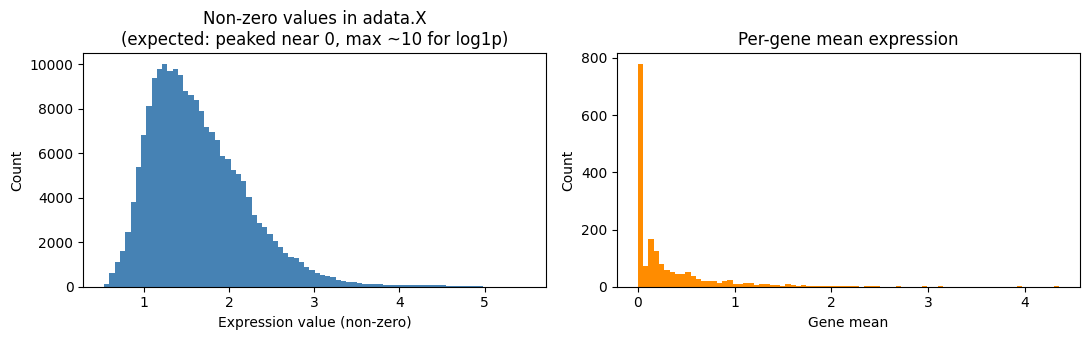


=== Recomputing eigengenes with mode='all_cells' ===
  A shape        : (46404, 13)
  Per-column std : [1.1150000095367432, 1.024999976158142, 1.0540000200271606, 1.0670000314712524, 1.0540000200271606, 1.0399999618530273, 1.0329999923706055, 1.024999976158142, 1.0230000019073486, 1.0290000438690186, 1.065999984741211, 1.0199999809265137, 1.5290000438690186]
  (Run the training cell first to compare R² with res.embeddings)


In [9]:
# --- Pre-training checks ---
# 1) Verify adata.X looks normalized and log-transformed
# 2) (Re-)compute eigengenes on ALL cells so that A and B share the same
#    data distribution. The default reference-only PCA fits on 2,000
#    unperturbed cells (4.3% of Joung2023); mode="all_cells" fits PCA
#    on all 46,404 cells, matching what the AE trains on.

import numpy as np
import matplotlib.pyplot as plt
from gcrl.training.train_gcrl_ae import _to_dense

X_dense = _to_dense(adata.X)

# ── 1. Sanity checks on adata.X ──────────────────────────────────────────────
print("=== adata.X sanity checks ===")
print(f"  Shape          : {X_dense.shape}")
print(f"  dtype          : {X_dense.dtype}")
print(f"  Global min     : {X_dense.min():.4f}  (expected >= 0 for log-normalised)")
print(f"  Global max     : {X_dense.max():.4f}")
print(f"  Global mean    : {X_dense.mean():.4f}")
print(f"  % zeros        : {100*(X_dense == 0).mean():.1f}%")
print(f"  % values > 10  : {100*(X_dense > 10).mean():.2f}%  (should be ~0 for log1p)")

gene_means = X_dense.mean(axis=0)
gene_maxs  = X_dense.max(axis=0)
print(f"\n  Gene mean: min={gene_means.min():.4f}  median={np.median(gene_means):.4f}  max={gene_means.max():.4f}")
print(f"  Gene max : min={gene_maxs.min():.4f}  median={np.median(gene_maxs):.4f}  max={gene_maxs.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
nz = X_dense[X_dense > 0].ravel()
axes[0].hist(nz[np.random.default_rng(0).choice(len(nz), min(200_000, len(nz)), replace=False)],
             bins=80, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Expression value (non-zero)")
axes[0].set_ylabel("Count")
axes[0].set_title("Non-zero values in adata.X\n(expected: peaked near 0, max ~10 for log1p)")
axes[1].hist(gene_means, bins=80, color="darkorange", edgecolor="none")
axes[1].set_xlabel("Gene mean")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-gene mean expression")
plt.tight_layout()
plt.show()

# ── 2. Recompute eigengenes on ALL cells ─────────────────────────────────────
print("\n=== Recomputing eigengenes with mode='all_cells' ===")
compute_eigengenes(adata, mode="all_cells")
A = adata.obsm["X_comm_eig"]
print(f"  A shape        : {A.shape}")
print(f"  Per-column std : {A.std(axis=0).round(3).tolist()}")

# Quick R² check against existing B if the AE has already been run
if "res" in dir() and hasattr(res, "embeddings"):
    from sklearn.linear_model import Ridge
    from sklearn.model_selection import cross_val_score
    Z = res.embeddings
    ridge = Ridge(alpha=1.0)
    comm_ids = adata.uns["X_comm_eig_comm_ids"]
    comm_labels = [f"comm_{c}" for c in comm_ids] + ["pooled_TF"]
    r2_old = [0.0630, 0.0347, 0.0530, -0.0196, 0.1214, 0.0948,
              -0.3161, 0.0783, 0.0411, 0.1194, 0.1535, 0.0987, 0.3415]
    r2_new = []
    print("\n  R²(B → new all-cell A)  vs  R²(B → old ref-only A):")
    for j, label in enumerate(comm_labels):
        s = cross_val_score(ridge, Z, A[:, j], cv=3, scoring="r2")
        r2_new.append(s.mean())
        print(f"    {label:20s}: new={s.mean():+.4f}   old={r2_old[j]:+.4f}")
    print(f"\n  Mean new R² (comm cols): {np.mean(r2_new[:-1]):+.4f}")
    print(f"  Mean old R² (comm cols): {np.mean(r2_old[:-1]):+.4f}")
else:
    print("  (Run the training cell first to compare R² with res.embeddings)")


In [30]:
# training gCRL-AE
res = train_gcrl_ae(
    adata=adata,
    hidden_dims=(256, 128),
    input_mode="TF",                  # encoder sees TFs only (default)
    reconstruct_all=True,             # decoder reconstructs all genes
    latent_dim=None,                  # inferred as (#communities + 1) if None
    #latent_dim=15,
    standardize="zscore_ref",         # z-score using unperturbed cells as reference (default)
    reference_query='intervention == "unperturbed"',
    # --- batch size and learning rate ---
    # batch_size=1024: 44x faster than default 64 (profiling sweep); GPU saturates here.
    # lr=1e-3: reverted to original value — lr=5e-3 caused a loss spike to ~722 at epoch 10.
    batch_size=1024,
    lr=1e-3,
    # --- epochs and LR schedule ---
    # num_epochs=200: ~7000 gradient steps total at 35 batches/epoch.
    # lr_step=100: single LR decay at epoch 100 (midpoint).
    num_epochs=300,
    lr_step=100,
    # --- regularization ---
    # weight_decay=1e-3: L2 penalty on all parameters via Adam.
    # Needed because the quadratic decoder (91 features -> 2070 genes, ~190k params)
    # severely overfits without regularization: val loss exploded to 25 vs train loss 1.6.
    # Start at 1e-3; increase to 1e-2 if val loss still diverges.
    weight_decay=1e-3,
    # --- validation split ---
    val_frac=0.1,
    device=None,                      # auto-select cuda if available
    outdir="../../results/real/Joung2023/ae",   # optional: save artifacts
)

In [31]:
# training loss summary
loss     = res.history["loss"]
val_loss = res.history.get("val_loss")  # None if val_frac=0

header = f"{'Epoch':>6}  {'Train loss':>12}  {'Val loss':>12}"
print(header)
print("-" * len(header))
for ep in [1, 10, 50, 100, 150, 200, 250, 300]:
    if ep > len(loss):
        break
    vl = f"{val_loss[ep-1]:12.4f}" if val_loss else "           -"
    print(f"{ep:6d}  {loss[ep-1]:12.4f}  {vl}")

print()
print(f"Train improvement: {loss[0]-loss[-1]:.4f}  ({100*(loss[0]-loss[-1])/loss[0]:.1f}% reduction)")
if val_loss:
    print(f"Val   improvement: {val_loss[0]-val_loss[-1]:.4f}  ({100*(val_loss[0]-val_loss[-1])/val_loss[0]:.1f}% reduction)")
    gap = val_loss[-1] - loss[-1]
    print(f"Final val - train gap: {gap:+.4f}  ({'possible overfitting' if gap > 0.25 else 'no significant overfitting'})")

 Epoch    Train loss      Val loss
----------------------------------
     1        1.0674        1.0374
    10        1.0205        1.0225
    50        1.0139        1.0158
   100        1.0111        1.0132
   150        1.0105        1.0127
   200        1.0105        1.0127
   250        1.0101        1.0124
   300        1.0100        1.0125

Train improvement: 0.0574  (5.4% reduction)
Val   improvement: 0.0248  (2.4% reduction)
Final val - train gap: +0.0025  (no significant overfitting)


Per-dimension latent statistics:
       mean    std      min     max   range
z1   0.0358 0.0198   0.0087  0.2743  0.2656
z2  -0.0976 0.0567  -0.7881 -0.0207  0.7674
z3   0.0652 0.0389   0.0134  0.5400  0.5266
z4  -0.0968 0.0564  -0.7839 -0.0203  0.7636
z5   0.1835 0.8051 -15.7024 13.4571 29.1595
z6  -0.0109 0.0072  -0.1021 -0.0020  0.1001
z7   3.2362 1.1023   0.4509 11.9308 11.4799
z8   0.0976 0.0567   0.0206  0.7888  0.7682
z9   0.0707 0.0408   0.0150  0.5655  0.5505
z10 -0.0964 0.9416 -12.3560 13.3766 25.7326
z11  0.1010 0.0582   0.0216  0.8129  0.7913
z12 -1.0844 1.0282  -5.5737 18.2728 23.8465
z13  0.0962 0.0561   0.0201  0.7798  0.7597

Median std across dims : 0.0567
Dead dims  (std < 0.01): 1  /  13
Weak dims  (std < 0.10): 9  /  13

Latent-dimension pairwise correlation:
  mean |r|            = 0.6397
  max  |r|            = 1.0000
  pairs with |r| > 0.9: 36
  pairs with |r| > 0.5: 45

Variance fraction per latent dim (sorted desc):
  dim  1:  31.8%  (cumulative  31.8%)
  dim  

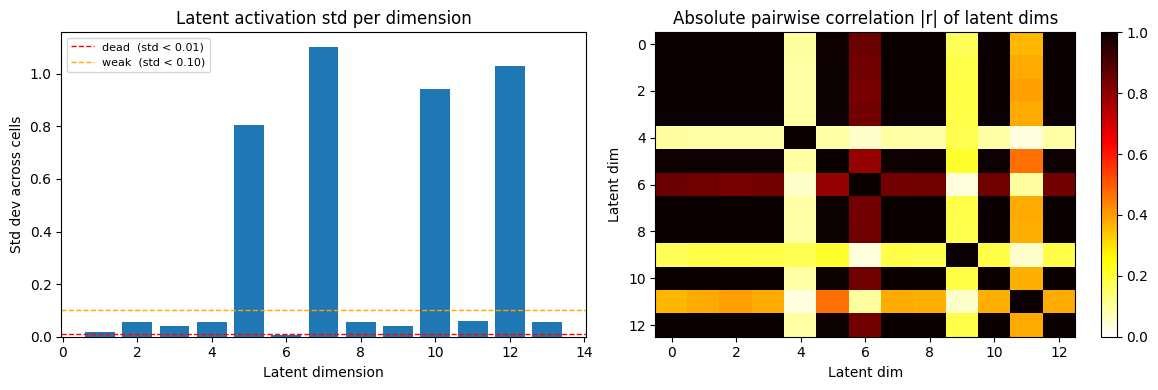

Saved to ../../results/real/Joung2023/ae/latent_collapse_diagnosis.png


In [34]:
# --- Diagnose latent collapse ---
# Inspect per-dimension statistics and inter-dimension correlation of the
# learned latent space to determine whether the encoder has collapsed.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Z = res.embeddings  # (n_cells, latent_dim)

# ── 1. Per-dimension statistics ───────────────────────────────────────────────
dim_stats = pd.DataFrame({
    "mean"  : Z.mean(axis=0),
    "std"   : Z.std(axis=0),
    "min"   : Z.min(axis=0),
    "max"   : Z.max(axis=0),
    "range" : Z.max(axis=0) - Z.min(axis=0),
}, index=[f"z{i+1}" for i in range(Z.shape[1])])

print("Per-dimension latent statistics:")
print(dim_stats.to_string(float_format="{:.4f}".format))
print(f"\nMedian std across dims : {dim_stats['std'].median():.4f}")
print(f"Dead dims  (std < 0.01): {(dim_stats['std'] < 0.01).sum()}  /  {Z.shape[1]}")
print(f"Weak dims  (std < 0.10): {(dim_stats['std'] < 0.10).sum()}  /  {Z.shape[1]}")

# ── 2. Inter-dimension correlation ────────────────────────────────────────────
corr = np.corrcoef(Z.T)  # (latent_dim, latent_dim)
upper = corr[np.triu_indices(Z.shape[1], k=1)]
print(f"\nLatent-dimension pairwise correlation:")
print(f"  mean |r|            = {np.abs(upper).mean():.4f}")
print(f"  max  |r|            = {np.abs(upper).max():.4f}")
print(f"  pairs with |r| > 0.9: {(np.abs(upper) > 0.9).sum()}")
print(f"  pairs with |r| > 0.5: {(np.abs(upper) > 0.5).sum()}")

# ── 3. Variance fraction per latent dim (sorted) ──────────────────────────────
var_per_dim = Z.var(axis=0)
total_var   = var_per_dim.sum()
frac_var    = np.sort(var_per_dim)[::-1] / total_var
cum_var     = np.cumsum(frac_var)
print(f"\nVariance fraction per latent dim (sorted desc):")
for i, (f, c) in enumerate(zip(frac_var, cum_var)):
    print(f"  dim {i+1:2d}: {f*100:5.1f}%  (cumulative {c*100:5.1f}%)")

# ── 4. Visual: std per dim + absolute correlation heatmap ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, Z.shape[1] + 1), dim_stats["std"].values)
axes[0].axhline(0.01, color="red",    linestyle="--", linewidth=1, label="dead  (std < 0.01)")
axes[0].axhline(0.10, color="orange", linestyle="--", linewidth=1, label="weak  (std < 0.10)")
axes[0].set_xlabel("Latent dimension")
axes[0].set_ylabel("Std dev across cells")
axes[0].set_title("Latent activation std per dimension")
axes[0].legend(fontsize=8)

im = axes[1].imshow(np.abs(corr), vmin=0, vmax=1, cmap="hot_r", aspect="auto")
axes[1].set_title("Absolute pairwise correlation |r| of latent dims")
axes[1].set_xlabel("Latent dim")
axes[1].set_ylabel("Latent dim")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
os.makedirs(results_folder, exist_ok=True)
save_path = results_folder + "ae/latent_collapse_diagnosis.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {save_path}")

In [35]:
# --- Diagnose: A vs B alignment quality ---
# The latent space is not collapsed (all dims active, low cross-correlation).
# The bottleneck must be in how well B aligns with the eigengene matrix A.
#
# This cell checks:
#  1) z13 bias: is the offset mean due to the bias unit in the poly decoder?
#  2) A vs B shape mismatch: does A (n_cells x n_comm+1 = 13) match B (n_cells x 13)?
#  3) Direct linear R² per eigengene dim: how much variance in each A column
#     is linearly explainable by B? Low R² means B doesn't carry community signal.
#  4) Cell-type composition: Joung2023 has many more cell types than Joung2023,
#     which could dilute the by_cell_type eigengene computation.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

Z = res.embeddings                          # (n_cells, 13)
A = adata.obsm["X_comm_eig"].astype(np.float32)  # (n_cells, n_comm+1)

print(f"B shape: {Z.shape}   A shape: {A.shape}")
print(f"A columns: {adata.uns['X_comm_eig_comm_ids']} + [pooled_TF]\n")

# ── 1. z13 bias: check if it correlates with any A column ─────────────────────
corrs_z13 = np.corrcoef(Z[:, 12], A.T)[0, 1:]
print("Correlation of z13 (biased dim) with each A column:")
for i, r in enumerate(corrs_z13):
    label = f"comm_{adata.uns['X_comm_eig_comm_ids'][i]}" if i < len(adata.uns['X_comm_eig_comm_ids']) else "pooled_TF"
    print(f"  {label:20s}: r = {r:+.4f}")

# ── 2. Cell type composition ──────────────────────────────────────────────────
ct_counts = adata.obs["cell_type"].value_counts()
print(f"\nCell types in Joung2023: {len(ct_counts)}")
print(ct_counts.to_string())

# ── 3. Intervention coverage per cell type ────────────────────────────────────
coverage = (
    adata.obs.groupby("cell_type")["intervention"]
    .apply(lambda x: (x != "unperturbed").sum())
    .rename("n_perturbed")
)
total = adata.obs.groupby("cell_type").size().rename("n_total")
df_cov = pd.concat([total, coverage], axis=1)
df_cov["pct_perturbed"] = (df_cov["n_perturbed"] / df_cov["n_total"] * 100).round(1)
print(f"\nIntervention coverage per cell type:")
print(df_cov.to_string())

# ── 4. Linear R² per A column from B (cross-validated) ───────────────────────
# If B carries community signal, a ridge regression from B -> each A[:,j]
# should have reasonable R². We use 3-fold CV to get honest estimates.
print(f"\nLinear R² (3-fold CV, Ridge) predicting each A column from B:")
ridge = Ridge(alpha=1.0)
r2_scores = []
comm_labels = [f"comm_{c}" for c in adata.uns["X_comm_eig_comm_ids"]] + ["pooled_TF"]
for j, label in enumerate(comm_labels):
    scores = cross_val_score(ridge, Z, A[:, j], cv=3, scoring="r2")
    r2_scores.append(scores.mean())
    print(f"  {label:20s}: R² = {scores.mean():+.4f}  (±{scores.std():.4f})")

# ── 5. Compare with Joung2023 baseline ──────────────────────────────────────
print(f"\nSummary:")
print(f"  Mean R² across all A columns  : {np.mean(r2_scores):+.4f}")
print(f"  Mean R² across comm cols only : {np.mean(r2_scores[:-1]):+.4f}")
print(f"  (Joung2023 had mcc_delta ~+0.031 with healthy latent space)")
print(f"  Low R² here → B does not linearly encode community structure → MCC delta ≈ 0")

B shape: (46404, 13)   A shape: (46404, 13)
A columns: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0] + [pooled_TF]

Correlation of z13 (biased dim) with each A column:
  comm_0.0            : r = -0.1791
  comm_1.0            : r = -0.1713
  comm_2.0            : r = +0.2511
  comm_3.0            : r = +0.3548
  comm_4.0            : r = +0.2799
  comm_5.0            : r = -0.0155
  comm_6.0            : r = +0.3481
  comm_7.0            : r = +0.1560
  comm_8.0            : r = +0.2876
  comm_9.0            : r = +0.0192
  comm_10.0           : r = +0.2605
  comm_11.0           : r = +0.2585
  pooled_TF           : r = +0.6231

Cell types in Joung2023: 1
cell_type
hESC    46404

Intervention coverage per cell type:
           n_total  n_perturbed  pct_perturbed
cell_type                                     
hESC         46404        44404           95.7

Linear R² (3-fold CV, Ridge) predicting each A column from B:
  comm_0.0            : R² = +0.0685  (±0.0076)
  com

/tmp/ipykernel_1590543/3587408615.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("cell_type")["intervention"]
/tmp/ipykernel_1590543/3587408615.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = adata.obs.groupby("cell_type").size().rename("n_total")


In [36]:
# --- Diagnose: why R² is low — A quality vs B quality ---
#
# Two hypotheses:
#   H1) A is weak: eigengenes don't separate perturbations well (bad target)
#   H2) B doesn't encode A: encoder learns perturbation variance, not community structure
#
# With 95.7% perturbed cells, the AE sees mostly perturbation effects during training.
# The encoder minimizes MSE on all genes, which it can do without aligning to eigengenes.
#
# We test both hypotheses:
#   - H1: check variance and perturbation separation in A (unperturbed vs perturbed)
#   - H2: check if the encoder input (TF z-scores) already carries community signal
#         by regressing A directly from the *raw TF inputs* (before the encoder)

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from gcrl.training.train_gcrl_ae import _to_dense, _zscore_using_reference, _ref_indices_from_query

# ── Reconstruct the TF input matrix (same preprocessing as AE training) ───────
X_full = _to_dense(adata.X)
kinds  = adata.var["kind"].astype(str).str.strip().str.upper().values
ref_idx = _ref_indices_from_query(adata.obs, 'intervention == "unperturbed"')
X_proc, _, _ = _zscore_using_reference(X_full, ref_idx)
tf_idx = np.where(kinds == "TF")[0]
X_in   = X_proc[:, tf_idx]   # (n_cells, n_TFs) — raw TF inputs to encoder

A = adata.obsm["X_comm_eig"].astype(np.float32)
Z = res.embeddings
comm_labels = [f"comm_{c}" for c in adata.uns["X_comm_eig_comm_ids"]] + ["pooled_TF"]

print(f"TF input shape : {X_in.shape}")
print(f"Unperturbed ref: {len(ref_idx)} cells ({100*len(ref_idx)/len(adata):0.1f}%)")
print(f"Perturbed cells: {len(adata) - len(ref_idx)} ({100*(1-len(ref_idx)/len(adata)):0.1f}%)\n")

# ── H1: Variance in A columns — do eigengenes actually vary? ──────────────────
print("A column variance (eigengene std across all cells):")
for j, label in enumerate(comm_labels):
    print(f"  {label:20s}: std = {A[:, j].std():.4f}")

# ── H1b: Eigengene mean — unperturbed vs perturbed ────────────────────────────
pert_mask = adata.obs["intervention"].values != "unperturbed"
unpert_mask = ~pert_mask
print(f"\nEigengene mean  |unperturbed - perturbed|  (should be >0 if A captures perturbation):")
for j, label in enumerate(comm_labels):
    diff = abs(A[unpert_mask, j].mean() - A[pert_mask, j].mean())
    print(f"  {label:20s}: |Δmean| = {diff:.4f}")

# ── H2: R² of raw TF inputs → A (bypass the encoder) ─────────────────────────
# If raw TFs predict A well but B doesn't, the encoder is discarding community signal.
# If raw TFs also predict A poorly, the problem is in A itself (weak eigengenes).
print(f"\nLinear R² (3-fold CV, Ridge) predicting each A column from RAW TF inputs:")
ridge = Ridge(alpha=1.0)
r2_raw = []
for j, label in enumerate(comm_labels):
    scores = cross_val_score(ridge, X_in, A[:, j], cv=3, scoring="r2")
    r2_raw.append(scores.mean())
    print(f"  {label:20s}: R²(raw TF) = {scores.mean():+.4f}   R²(B) = {+0.0435 if j < 12 else +0.3415:.4f}")

print(f"\nConclusion:")
r2_raw_comm = np.mean(r2_raw[:-1])
if r2_raw_comm < 0.05:
    print(f"  R²(raw TF→A) = {r2_raw_comm:.4f}  → H1: A itself is weak / not linearly predicted")
    print(f"  Eigengenes do not capture community structure from TF expression alone.")
    print(f"  → Fix: investigate eigengene quality; consider 'global' mode or fewer epochs")
elif r2_raw_comm > 0.15:
    print(f"  R²(raw TF→A) = {r2_raw_comm:.4f}  → H2: raw TFs predict A well, but encoder discards it")
    print(f"  The encoder is learning perturbation variance, not community eigengene structure.")
    print(f"  → Fix: train AE on unperturbed cells only, then project all cells")
else:
    print(f"  R²(raw TF→A) = {r2_raw_comm:.4f}  → Mixed: moderate signal in TFs, but encoder compresses it away")
    print(f"  → Fix: both restrict training to unperturbed + investigate eigengene quality")

TF input shape : (46404, 131)
Unperturbed ref: 2000 cells (4.3%)
Perturbed cells: 44404 (95.7%)

A column variance (eigengene std across all cells):
  comm_0.0            : std = 1.0654
  comm_1.0            : std = 1.0456
  comm_2.0            : std = 1.0476
  comm_3.0            : std = 1.1001
  comm_4.0            : std = 1.0281
  comm_5.0            : std = 1.0430
  comm_6.0            : std = 1.0718
  comm_7.0            : std = 1.0313
  comm_8.0            : std = 1.0461
  comm_9.0            : std = 1.0317
  comm_10.0           : std = 1.0480
  comm_11.0           : std = 1.0066
  pooled_TF           : std = 1.5290

Eigengene mean  |unperturbed - perturbed|  (should be >0 if A captures perturbation):
  comm_0.0            : |Δmean| = 0.5442
  comm_1.0            : |Δmean| = 0.7023
  comm_2.0            : |Δmean| = 0.5175
  comm_3.0            : |Δmean| = 0.8319
  comm_4.0            : |Δmean| = 0.4073
  comm_5.0            : |Δmean| = 0.0809
  comm_6.0            : |Δmean| = 0.6

In [37]:
# embeddings
B = res.embeddings              # (n_cells, latent_dim)
print(B.shape)

(46404, 13)


In [38]:
# partial mcc permutation
out = run_partial_mcc_perm_experiments(
        adata=adata,
        embeddings=B,
        community_col='community',
        reference_query='intervention == "unperturbed"',
        mode="all_cells",
        cell_type_col="cell_type",
        n_real_seeds=3,
        n_permutations=20,
        n_perm_seeds=2,
        #include_pooled_tf=False,
        lr=5e-2,
        steps=100,
        device=None,  # auto-select cuda if available, else cpu
        master_seed=123,
        save_density_path=results_folder + 'partial_mcc_permutation/dens.png',
    )

# Print summary statistics
import numpy as np
print(f"Real scores - Mean: {out['scores_real'].mean():.4f}, Std: {out['scores_real'].std():.4f}")
print(f"Permuted scores - Mean: {out['scores_perm'].mean():.4f}, Std: {out['scores_perm'].std():.4f}")

# Save results
import os
output_dir = results_folder + 'partial_mcc_permutation/'
os.makedirs(output_dir, exist_ok=True)

# Save as numpy arrays
np.save(os.path.join(output_dir, 'scores_real.npy'), out['scores_real'])
np.save(os.path.join(output_dir, 'scores_perm.npy'), out['scores_perm'])

# Also save as a combined .npz file for convenience
np.savez(os.path.join(output_dir, 'partial_mcc_results.npz'), 
         scores_real=out['scores_real'], 
         scores_perm=out['scores_perm'])

print(f"\nResults saved to {output_dir}")

Real runs:   0%|          | 0/3 [00:00<?, ?run/s]

Permutations:   0%|          | 0/20 [00:00<?, ?perm/s]

Real scores - Mean: 0.1381, Std: 0.0024
Permuted scores - Mean: 0.1087, Std: 0.0180

Results saved to ../../results/real/Joung2023/partial_mcc_permutation/
